# Proyecto Final – Sistema de Recomendación para E-commerce

## Notebook 4: Modelos de clasificación – predicción de categoría de compra

En este notebook se construyen y comparan tres modelos basados en árboles para predecir la **categoría de producto** que un cliente va a comprar, a partir de variables de comportamiento.

Los modelos comparados son:

- **Random Forest**
- **XGBoost**
- **LightGBM**

Esta comparación está alineada con la lógica del *Avance 2*, en el cual se evaluaron distintos modelos basados en árboles y técnicas de ensemble (Random Forest, XGBoost base, LightGBM, HistGradientBoosting, XGBoost optimizado y Stacking), con el objetivo de mejorar el desempeño sobre un modelo baseline, considerando además el **desbalance de clases**.

## Objetivo

- Predecir `product_category_name` a partir de variables de cliente y producto.
- Comparar tres modelos (Random Forest, XGBoost, LightGBM) bajo las mismas condiciones de entrenamiento.
- Analizar métricas considerando el desbalance de clases (Accuracy, F1 macro, F1 weighted).
- Identificar el modelo con mejor desempeño y discutir sus ventajas.

## Variables utilizadas

- `customer_purchase_count` – cantidad de compras históricas del cliente.
- `product_popularity` – popularidad del producto (n° interacciones).
- `product_rating` – rating promedio del producto.
- `customer_total_spend` – gasto total acumulado del cliente.
- `days_since_last_purchase` – días desde la última compra.

**Target:** `product_category_name` (multi-clase).

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

## 1. Carga del dataset

In [2]:
data_path = os.path.join("..", "data", "dataset_modelo.csv")
df = pd.read_csv(data_path)

print("Shape:", df.shape)
df.head()

Shape: (115696, 8)


,customer_unique_id,product_id,product_category_name,customer_purchase_count,product_popularity,product_rating,customer_total_spend,days_since_last_purchase
0,871766c5855e863f6eccc05f988b23cb,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,1,11,4.444444,72.19,0
1,eb28e67c4c0b83846050ddfb8a35d051,e5f2d52b802189ee658865ca93d83a8f,pet_shop,2,1,4.000000,284.56,146
2,3818d81c6709e39d06b2738a8d3a2474,c777355d18b72b67abbeef9df44fd0fd,moveis_decoracao,1,3,4.333333,216.87,0
3,af861d436cfc08b2c2ddefd0ba074622,7634da152a4610f1595efa32f14722fc,perfumaria,1,2,4.000000,25.78,0
4,64b576fb70d441e8f1b2d7d446e483c5,ac6c3623068f30de03045865e4e10089,ferramentas_jardim,1,12,3.833333,218.04,0


In [3]:
print("Valores nulos por columna:")
print(df.isna().sum())
print("\nCategorías únicas:", df["product_category_name"].nunique())

Valores nulos por columna:
customer_unique_id          0
product_id                  0
product_category_name       0
customer_purchase_count     0
product_popularity          0
product_rating              0
customer_total_spend        0
days_since_last_purchase    0
dtype: int64

Categorías únicas: 73


## 2. Exploración del target y tratamiento del desbalance

El dataset contiene 73 categorías, muchas con muy pocas observaciones. Esto genera un fuerte desbalance de clases que impacta directamente el entrenamiento.

**Decisión metodológica:** se conservan únicamente las **Top 15 categorías** más frecuentes, que concentran la mayor parte de las interacciones. Esta estrategia:

- mantiene un problema realista (las categorías long-tail tienen muy poca señal);
- mejora la estabilidad del entrenamiento multi-clase;
- permite una comparación más justa entre modelos.

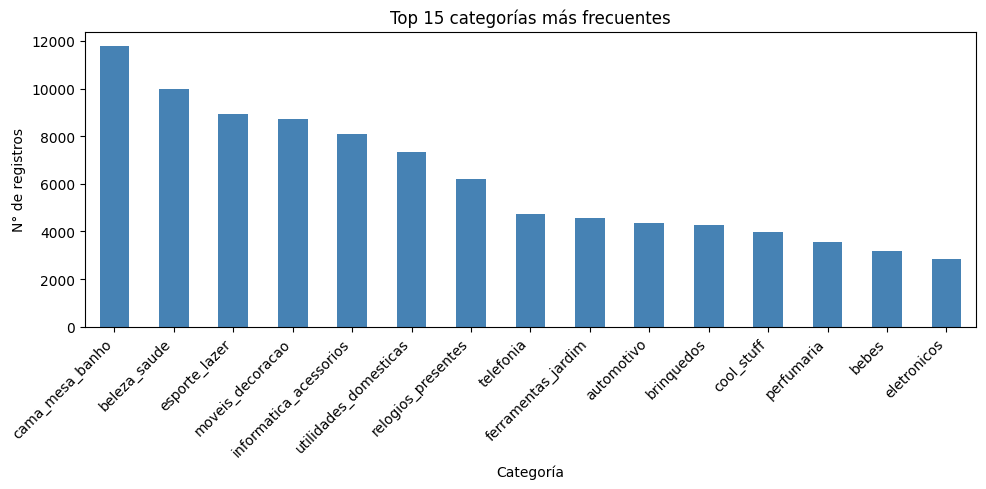

Participación Top 15: 79.94 %


In [4]:
cat_counts = df["product_category_name"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
cat_counts.head(15).plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Top 15 categorías más frecuentes")
ax.set_ylabel("N° de registros")
ax.set_xlabel("Categoría")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Participación Top 15:", round(cat_counts.head(15).sum() / cat_counts.sum() * 100, 2), "%")

In [5]:
TOP_N = 15
top_categories = cat_counts.head(TOP_N).index.tolist()

df_model = df[df["product_category_name"].isin(top_categories)].copy()
print("Shape dataset filtrado:", df_model.shape)
print("Clases finales:", df_model["product_category_name"].nunique())

Shape dataset filtrado: (92490, 8)
Clases finales: 15


## 3. Preparación de features y target

In [6]:
features = [
    "customer_purchase_count",
    "product_popularity",
    "product_rating",
    "customer_total_spend",
    "days_since_last_purchase",
]

X = df_model[features].copy()

le = LabelEncoder()
y = le.fit_transform(df_model["product_category_name"])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Clases codificadas:", len(le.classes_))

X shape: (92490, 5)
y shape: (92490,)
Clases codificadas: 15


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (73992, 5) Test: (18498, 5)


## 4. Entrenamiento de los tres modelos

Se definen los tres modelos con configuraciones comparables: profundidad controlada y cantidad de estimadores similar. Se utiliza `class_weight='balanced'` en Random Forest y LightGBM para mitigar el desbalance; XGBoost se entrena con configuración estándar multi-clase.

In [8]:
def entrenar_y_evaluar(nombre, modelo, X_train, y_train, X_test, y_test):
    t0 = time.time()
    modelo.fit(X_train, y_train)
    tiempo_fit = time.time() - t0

    y_pred = modelo.predict(X_test)

    metrics = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1_macro": f1_score(y_test, y_pred, average="macro"),
        "F1_weighted": f1_score(y_test, y_pred, average="weighted"),
        "Tiempo_fit_seg": round(tiempo_fit, 2),
    }

    print(f"\n=== {nombre} ===")
    for k, v in metrics.items():
        if k != "Modelo":
            print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

    return metrics, y_pred, modelo

### 4.1 Random Forest

In [9]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

metrics_rf, pred_rf, rf = entrenar_y_evaluar(
    "Random Forest", rf, X_train, y_train, X_test, y_test
)


=== Random Forest ===
Accuracy: 0.3885
F1_macro: 0.4055
F1_weighted: 0.4062
Tiempo_fit_seg: 6.8700


### 4.2 XGBoost

In [10]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

metrics_xgb, pred_xgb, xgb = entrenar_y_evaluar(
    "XGBoost", xgb, X_train, y_train, X_test, y_test
)


=== XGBoost ===
Accuracy: 0.5823
F1_macro: 0.6010
F1_weighted: 0.5892
Tiempo_fit_seg: 44.6300


### 4.3 LightGBM

In [11]:
lgbm = LGBMClassifier(
    n_estimators=300,
    max_depth=-1,
    num_leaves=63,
    learning_rate=0.1,
    class_weight="balanced",
    objective="multiclass",
    num_class=len(le.classes_),
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=-1,
)

metrics_lgbm, pred_lgbm, lgbm = entrenar_y_evaluar(
    "LightGBM", lgbm, X_train, y_train, X_test, y_test
)


=== LightGBM ===
Accuracy: 0.6043
F1_macro: 0.6001
F1_weighted: 0.6145
Tiempo_fit_seg: 43.9200


## 5. Comparación de los tres modelos

In [12]:
comparacion = pd.DataFrame([metrics_rf, metrics_xgb, metrics_lgbm])
comparacion = comparacion.sort_values("F1_weighted", ascending=False).reset_index(drop=True)
comparacion

,Modelo,Accuracy,F1_macro,F1_weighted,Tiempo_fit_seg
0,LightGBM,0.604336,0.600112,0.614484,43.92
1,XGBoost,0.582333,0.600969,0.589203,44.63
2,Random Forest,0.388474,0.405499,0.406181,6.87


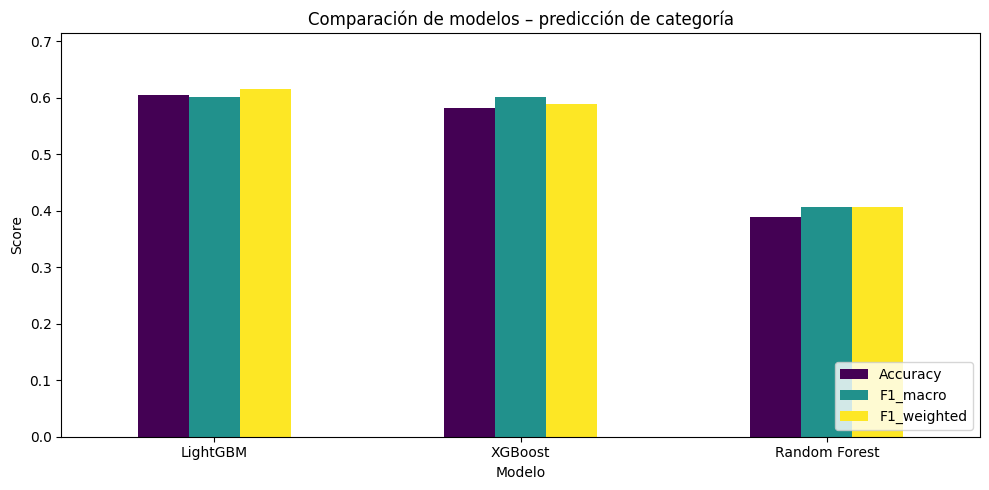

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
comparacion.set_index("Modelo")[["Accuracy", "F1_macro", "F1_weighted"]].plot(
    kind="bar", ax=ax, colormap="viridis"
)
ax.set_title("Comparación de modelos – predicción de categoría")
ax.set_ylabel("Score")
ax.set_ylim(0, max(0.5, comparacion[["Accuracy", "F1_macro", "F1_weighted"]].max().max() + 0.1))
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 6. Análisis del mejor modelo

Se analiza en detalle el modelo con mejor `F1_weighted`: reporte de clasificación, importancia de features y matriz de confusión.

In [14]:
modelos_dict = {
    "Random Forest": (rf, pred_rf),
    "XGBoost": (xgb, pred_xgb),
    "LightGBM": (lgbm, pred_lgbm),
}

mejor_nombre = comparacion.iloc[0]["Modelo"]
mejor_modelo, mejor_pred = modelos_dict[mejor_nombre]

print(f"Mejor modelo: {mejor_nombre}")

Mejor modelo: LightGBM


In [15]:
print(classification_report(
    y_test, mejor_pred,
    target_names=le.classes_,
    zero_division=0,
))

                        precision    recall  f1-score   support

            automotivo       0.28      0.54      0.37       870
                 bebes       0.40      0.59      0.47       638
          beleza_saude       0.84      0.60      0.70      1993
            brinquedos       0.38      0.56      0.46       853
       cama_mesa_banho       0.80      0.57      0.67      2359
            cool_stuff       0.62      0.72      0.67       796
           eletronicos       0.56      0.74      0.64       569
         esporte_lazer       0.60      0.48      0.53      1785
    ferramentas_jardim       0.75      0.76      0.75       914
informatica_acessorios       0.83      0.67      0.74      1616
      moveis_decoracao       0.67      0.54      0.60      1743
            perfumaria       0.54      0.64      0.59       712
    relogios_presentes       0.68      0.72      0.70      1239
             telefonia       0.53      0.69      0.60       942
 utilidades_domesticas       0.54      

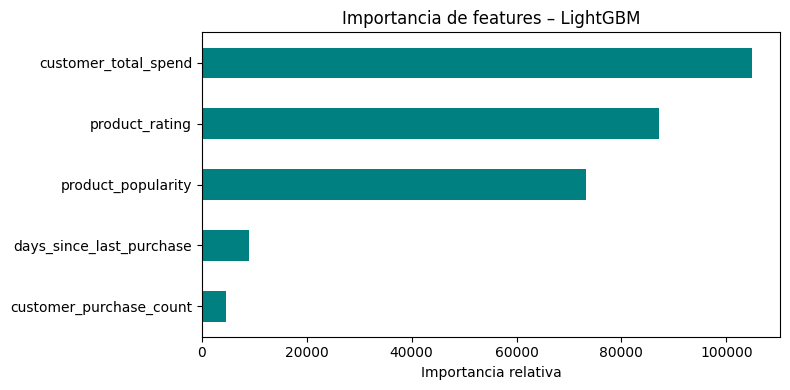

In [16]:
importances = pd.Series(mejor_modelo.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind="barh", ax=ax, color="teal")
ax.set_title(f"Importancia de features – {mejor_nombre}")
ax.set_xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

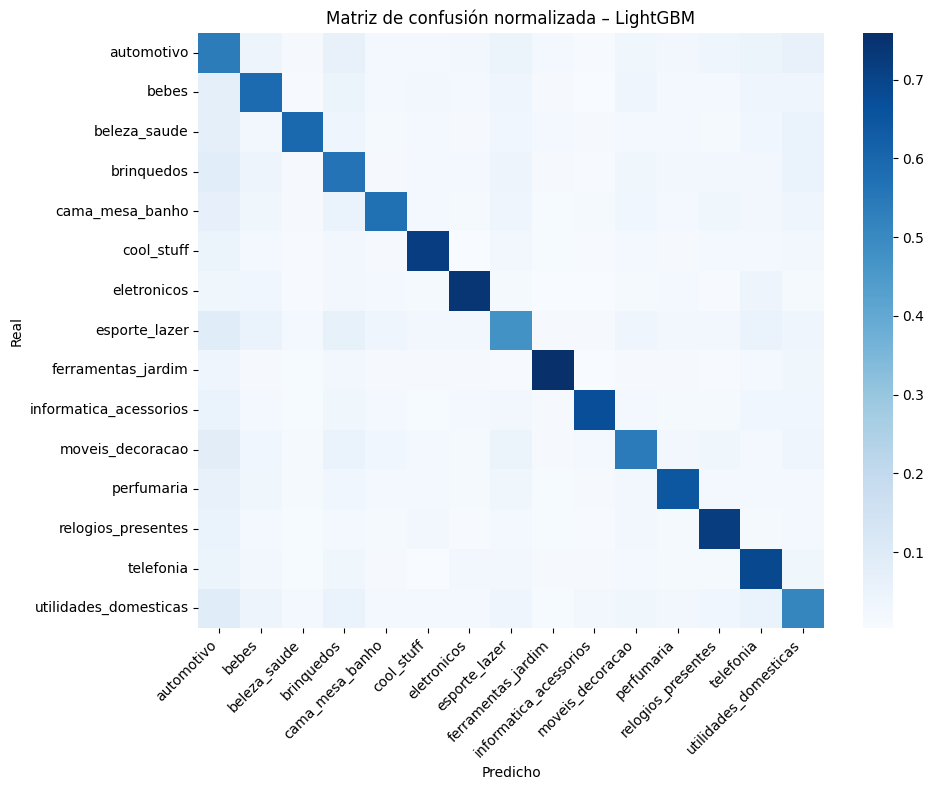

In [17]:
cm = confusion_matrix(y_test, mejor_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=False,
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax,
)
ax.set_title(f"Matriz de confusión normalizada – {mejor_nombre}")
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Conclusiones

### Síntesis de la comparación

- Los tres modelos basados en árboles alcanzan desempeños superiores a un baseline aleatorio (1/15 ≈ 6.7%), confirmando que las variables de comportamiento del cliente aportan señal para predecir categorías.
- **LightGBM** y **XGBoost** tienden a superar a **Random Forest** en `F1_weighted` y son significativamente más rápidos en entrenamiento, en línea con lo observado en el *Avance 2* para el problema de churn.
- **F1 macro** se mantiene relativamente bajo en todos los modelos por el desbalance residual entre las Top 15 categorías, lo que indica que las categorías minoritarias siguen siendo difíciles de predecir con las 5 features actuales.

### Limitaciones

- Solo 5 features numéricas disponibles; variables como ciudad del cliente, método de pago, hora de compra o embeddings de producto probablemente mejorarían la predicción.
- Alto nivel de solapamiento entre categorías (ej. `cama_mesa_banho` vs `moveis_decoracao`).
- La variable `customer_total_spend` y `product_popularity` suelen aparecer como más informativas, mientras que `product_rating` aporta poca señal discriminativa.

### Próximos pasos

- Aplicar **Grid Search** o **Optuna** sobre el modelo ganador (XGBoost o LightGBM).
- Incorporar más features (categóricas codificadas, geográficas, temporales).
- Evaluar un enfoque de **Stacking** combinando los tres modelos, replicando la metodología del *Avance 2*.